In [1]:
import time
from multiprocessing import Pool, get_context

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('pgf.mplstyle')
plt.rcParams.update({
    "pgf.preamble": "\n".join([
        r"\usepackage{newpxmath}",
        r"\usepackage{newpxtext}",
    ]),
})

from qpotts import PottsModel, Start

FIG_PATH = '../results/'

In [10]:
L = 100
T_min = 0.2
T_max = 2
steps = 50
T_range = np.linspace(T_min, T_max, steps)

In [ ]:
def curie_temp(q: int):
    return 1 / (np.log(1 + np.sqrt(q)))

def batch_means_method(arr: np.ndarray, min_num_blocks = 8):
    sigma_list = []
    while True:
        sigma = arr.std(ddof=1) / np.sqrt(arr.size)
        sigma_list.append(sigma)

        if (arr.size <= min_num_blocks):
            break

        arr = arr.reshape(-1, 2).mean(axis=1)

    return np.max(sigma_list)



def get_means(q: int):
    start_time = time.perf_counter()

    pm = PottsModel(L, T_range[0], q, Start.Cold)
    pm.sample_metropolis(0, 1_000_000)

    E_means = []
    std_list = []
    for T in T_range:
        pm.set_temperature(T)
        energies = pm.sample_metropolis(2**22, 20_000_000)
        E_means.append(np.mean(energies))
        std_list.append(batch_means_method(energies))

    end_time = time.perf_counter()
    print(f"Elapsed time: {end_time-start_time:.2f}s (q = {q})")

    return q, E_means, std_list

In [19]:
mp = get_context("fork")
with mp.Pool(2) as pool:
    results = list(pool.imap(get_means, [2, 10]))

Elapsed time: 38.27s (q = 2)
Elapsed time: 39.04s (q = 10)


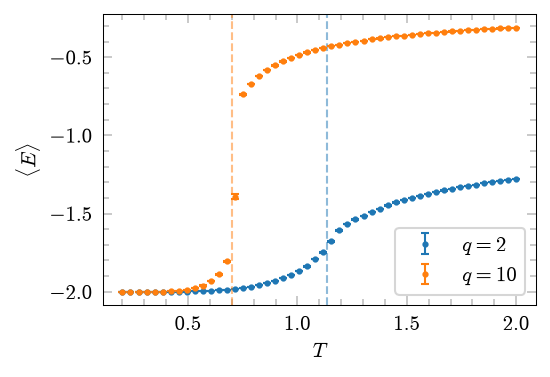

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5), dpi=150)
for q, E_means, std_list in results:
    # line, = ax.plot(T_range, E_means, '.', markersize=4, label=f"q={q}")
    ebc = ax.errorbar(T_range, E_means, std_list, fmt='.', markersize=4, capsize=2, label=fr"$q={q}$")
    line = ebc.lines[0]
    ax.axvline(x=curie_temp(q),c=line.get_color(), ls='--', alpha=0.5)

ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$\langle E \rangle$")

ax.legend()
plt.savefig(FIG_PATH + "temperature_sweep.pdf", bbox_inches='tight', backend='pgf')
plt.show()